# Блок B2.5: Granger-каузальность и VAR на конкретных эмоциях

**Контекст:** в Блоке B2 на агрегированном эмоциональном факторе F4 связь с инфляцией не выявлена. Однако в Блоке A.5 был обнаружен значимый Granger-эффект для **отдельных эмоциональных рядов** (Uncertainty, p=0.003 на лаге 2).

Это методологически важно: **факторизация может размывать конкретные сигналы**, а DFM усредняет дисперсию по всем эмоциям, в то время как реальная связь с инфляцией может быть свойством одной-двух конкретных категорий.

**Цель этого блока:** формально протестировать связь конкретных эмоций (а не агрегированного фактора) с инфляцией через VAR + Granger + IRF.

**Что делаем:**
1. Multivariate VAR(p) на наборе [CPI, d_p_Uncertainty, d_p_Anxiety, d_p_Disappointment]
2. Полный набор Granger-тестов
3. IRF: отклик инфляции на шоки конкретных эмоций
4. FEVD: вклад каждой эмоции в дисперсию инфляции
5. Робастность на y/y инфляции и на 48-месячном окне

## 1. Подготовка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DIPLOMA = '/content/drive/MyDrive/diploma'

panel = pd.read_csv(f'{DIPLOMA}/monthly_panel_with_diffs.csv', index_col=0, parse_dates=True)
panel.index.name = 'date'
print(f'Панель: {panel.shape}')

# Выбираем рабочие переменные
# CPI — m/m % с устранённой сезонностью (это уже стационарный ряд)
# Эмоции — в первых разностях, как мы установили в A.5 что они I(1)
WORK_VARS = ['Все товары и услуги', 'd_p_Uncertainty_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean']
data = panel.loc['2020-02-01':'2026-03-31', WORK_VARS].dropna().copy()

# Переименуем для удобства
data.columns = ['CPI', 'dUNC', 'dANX', 'dDIS']
print(f'\nИтоговый набор: {data.shape}')
print(f'Период: {data.index.min():%Y-%m} — {data.index.max():%Y-%m}')
print(f'\nПервые 3 строки:')
print(data.head(3).round(3))

# Стационарность
print('\nADF-тесты:')
for c in data.columns:
    s, p, *_ = adfuller(data[c], autolag='AIC')
    print(f'  {c:8s}: ADF stat={s:.3f}, p={p:.4f} → {"I(0)" if p<0.05 else "I(1)?"}')

Панель: (75, 76)

Итоговый набор: (74, 4)
Период: 2020-02 — 2026-03

Первые 3 строки:
              CPI   dUNC   dANX   dDIS
date                                  
2020-02-01  0.193  0.003  0.098 -0.007
2020-03-01  0.534 -0.017  0.103 -0.006
2020-04-01  0.809  0.003 -0.042 -0.003

ADF-тесты:
  CPI     : ADF stat=-6.689, p=0.0000 → I(0)
  dUNC    : ADF stat=-4.723, p=0.0001 → I(0)
  dANX    : ADF stat=-10.616, p=0.0000 → I(0)
  dDIS    : ADF stat=-8.209, p=0.0000 → I(0)


## 2. Парные Granger-тесты

Тестируем для каждой эмоции отдельно: помогает ли она предсказывать CPI?

In [ ]:
def granger_summary(df, dependent, predictor, maxlag=6):
    sub = df[[dependent, predictor]].dropna()
    res = grangercausalitytests(sub[[dependent, predictor]], maxlag=maxlag, verbose=False)
    rows = []
    for lag in range(1, maxlag + 1):
        f_stat = res[lag][0]['ssr_ftest'][0]
        f_p = res[lag][0]['ssr_ftest'][1]
        rows.append({
            'lag': lag, 'F-stat': round(f_stat, 3), 'p-value': round(f_p, 4),
            'sig': '***' if f_p < 0.01 else ('**' if f_p < 0.05 else ('*' if f_p < 0.10 else ''))
        })
    return pd.DataFrame(rows)

for emo in ['dUNC', 'dANX', 'dDIS']:
    print(f'\n{"="*60}')
    print(f'H0: {emo} НЕ Granger-causes CPI (т.е. эмоция не предсказывает инфляцию)')
    print(f'{"="*60}')
    g = granger_summary(data, dependent='CPI', predictor=emo, maxlag=6)
    print(g.to_string(index=False))

    # Контртест
    print(f'\nКонтртест: CPI → {emo}')
    g_rev = granger_summary(data, dependent=emo, predictor='CPI', maxlag=6)
    print(g_rev.to_string(index=False))


H0: dUNC НЕ Granger-causes CPI (т.е. эмоция не предсказывает инфляцию)
 lag  F-stat  p-value sig
   1   0.294   0.5895    
   2   6.365   0.0029 ***
   3   4.176   0.0092 ***
   4   2.978   0.0259  **
   5   2.537   0.0382  **
   6   2.008   0.0802   *

Контртест: CPI → dUNC
 lag  F-stat  p-value sig
   1   1.744   0.1909    
   2   5.406   0.0067 ***
   3   3.250   0.0274  **
   4   2.677   0.0400  **
   5   2.423   0.0461  **
   6   1.968   0.0861   *

H0: dANX НЕ Granger-causes CPI (т.е. эмоция не предсказывает инфляцию)
 lag  F-stat  p-value sig
   1   2.214   0.1413    
   2   1.413   0.2507    
   3   2.095   0.1096    
   4   3.223   0.0183  **
   5   2.861   0.0224  **
   6   2.688   0.0233  **

Контртест: CPI → dANX
 lag  F-stat  p-value sig
   1   0.001   0.9740    
   2   0.907   0.4085    
   3   0.549   0.6507    
   4   0.855   0.4961    
   5   0.974   0.4417    
   6   0.874   0.5201    

H0: dDIS НЕ Granger-causes CPI (т.е. эмоция не предсказывает инфляцию)
 lag  F-st

## 3. Multivariate VAR на 4 переменных + выбор лага

In [ ]:
# Селектор лагов
var_select = VAR(data).select_order(maxlags=6)
print('=== Информационные критерии (multivariate) ===')
print(var_select.summary())

# Выбираем лаг по AIC (с ограничением для устойчивости)
ic_aic = var_select.aic
ic_bic = var_select.bic
best_lag = max(1, min(3, int(np.median([ic_aic, ic_bic]))))
print(f'\nИтоговый выбор лага: p = {best_lag}')

var_results = VAR(data).fit(maxlags=best_lag, ic=None)
print(f'\n--- VAR({best_lag}) подогнан ---')
print(f'AIC: {var_results.aic:.3f}, BIC: {var_results.bic:.3f}')
print(f'Уравнение CPI:')
print(var_results.summary().__repr__()[:3000])

=== Информационные критерии (multivariate) ===
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -28.34     -28.21*   4.920e-13     -28.29*
1      -28.28      -27.63   5.243e-13      -28.02
2     -28.41*      -27.24  4.616e-13*      -27.94
3      -28.19      -26.49   5.831e-13      -27.52
4      -28.02      -25.80   7.107e-13      -27.14
5      -27.87      -25.13   8.557e-13      -26.78
6      -27.95      -24.68   8.417e-13      -26.65
-------------------------------------------------

Итоговый выбор лага: p = 1

--- VAR(1) подогнан ---
AIC: -27.706, BIC: -27.078
Уравнение CPI:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 02, May, 2026
Time:                     02:10:47
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -27.

## 4. IRF: отклик инфляции на шоки каждой эмоции

Cholesky-порядок: эмоции идут перед CPI (предположение, что эмоции могут влиять на инфляцию мгновенно, но не наоборот). Порядок эмоций между собой: dUNC, dANX, dDIS — стандартный по содержательной логике (от наиболее когнитивной — неопределённость — к более аффективным).

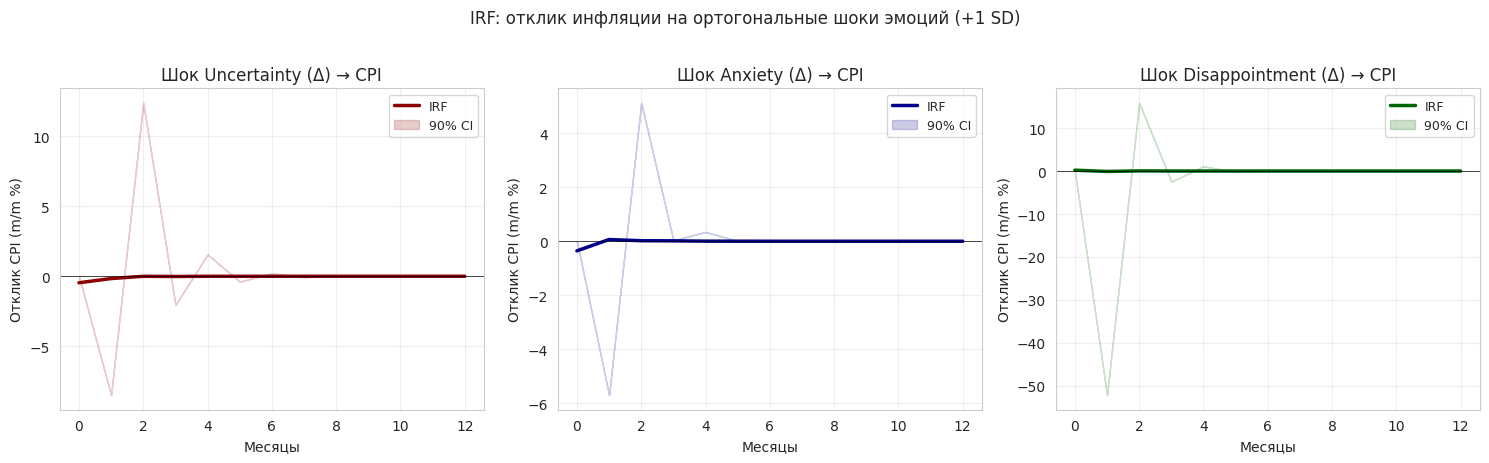


=== Числовой отклик CPI на шок каждой эмоции +1 SD ===

Шок Uncertainty (Δ):
  Месяц  1: -0.1631 [90% CI: -8.4977, -8.4977] *
  Месяц  2: -0.0030 [90% CI: +12.3934, +12.3934] *
  Месяц  3: -0.0155 [90% CI: -2.0500, -2.0500] *
  Месяц  6: -0.0001 [90% CI: +0.2154, +0.2154] *
  Месяц 12: -0.0000 [90% CI: +0.0007, +0.0007] *

Шок Anxiety (Δ):
  Месяц  1: +0.0630 [90% CI: -5.6906, -5.6906] *
  Месяц  2: +0.0197 [90% CI: +5.1148, +5.1148] *
  Месяц  3: +0.0152 [90% CI: +0.0325, +0.0325] *
  Месяц  6: +0.0005 [90% CI: +0.0306, +0.0306] *
  Месяц 12: +0.0000 [90% CI: +0.0001, +0.0001] *

Шок Disappointment (Δ):
  Месяц  1: -0.1008 [90% CI: -52.1308, -52.1308] *
  Месяц  2: +0.0328 [90% CI: +15.8347, +15.8347] *
  Месяц  3: +0.0011 [90% CI: -2.4585, -2.4585] *
  Месяц  6: +0.0004 [90% CI: +0.1171, +0.1171] *
  Месяц 12: +0.0000 [90% CI: +0.0003, +0.0003] *


In [ ]:
# Переупорядочиваем: эмоции первыми, CPI последний
data_ordered = data[['dUNC', 'dANX', 'dDIS', 'CPI']]
var_ord = VAR(data_ordered).fit(maxlags=best_lag, ic=None)
irf = var_ord.irf(periods=12)

# Bootstrap CI
ci_lo, ci_hi = irf.errband_mc(repl=300, signif=0.10, seed=42, burn=100)

# Главные графики: отклик CPI на шоки каждой эмоции
cpi_idx = list(data_ordered.columns).index('CPI')
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
emo_names = ['dUNC', 'dANX', 'dDIS']
emo_titles = ['Uncertainty (Δ)', 'Anxiety (Δ)', 'Disappointment (Δ)']
colors = ['darkred', 'darkblue', 'darkgreen']

for ax, emo, title, color in zip(axes, emo_names, emo_titles, colors):
    j_shk = list(data_ordered.columns).index(emo)
    irf_vals = irf.orth_irfs[:, cpi_idx, j_shk]
    ax.plot(range(13), irf_vals, color=color, linewidth=2.5, label='IRF')
    ax.fill_between(range(13), ci_lo[:, cpi_idx, j_shk], ci_hi[:, cpi_idx, j_shk],
                    alpha=0.2, color=color, label='90% CI')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'Шок {title} → CPI')
    ax.set_xlabel('Месяцы')
    ax.set_ylabel('Отклик CPI (m/m %)')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('IRF: отклик инфляции на ортогональные шоки эмоций (+1 SD)', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIPLOMA}/irf_individual_emotions.png', dpi=150, bbox_inches='tight')
plt.show()

# Числовая таблица для каждой эмоции
print('\n=== Числовой отклик CPI на шок каждой эмоции +1 SD ===')
for emo, title in zip(emo_names, emo_titles):
    j_shk = list(data_ordered.columns).index(emo)
    print(f'\nШок {title}:')
    for h in [1, 2, 3, 6, 12]:
        val = irf.orth_irfs[h, cpi_idx, j_shk]
        lo = ci_lo[h, cpi_idx, j_shk]
        hi = ci_hi[h, cpi_idx, j_shk]
        sig = '*' if (lo > 0 and hi > 0) or (lo < 0 and hi < 0) else ''
        print(f'  Месяц {h:2d}: {val:+.4f} [90% CI: {lo:+.4f}, {hi:+.4f}] {sig}')

## 5. FEVD: разложение дисперсии CPI

In [ ]:
fevd = var_ord.fevd(periods=12)
fevd_arr = np.array(fevd.decomp)  # shape: (n_vars, T_horizons, n_vars)

print(f'Форма FEVD: {fevd_arr.shape}')
print(f'Переменные: {list(data_ordered.columns)}')

# fevd_arr[i_response, h, j_shock]
cpi_idx = list(data_ordered.columns).index('CPI')

rows = []
for h in [1, 3, 6, 12]:
    if h - 1 < fevd_arr.shape[1]:
        decomp_h = fevd_arr[cpi_idx, h - 1, :]  # вклад каждого шока в CPI на горизонте h
        rows.append({
            'horizon': h,
            'shock_dUNC_%': round(decomp_h[0] * 100, 2),
            'shock_dANX_%': round(decomp_h[1] * 100, 2),
            'shock_dDIS_%': round(decomp_h[2] * 100, 2),
            'shock_CPI_%': round(decomp_h[3] * 100, 2),
        })

fevd_table = pd.DataFrame(rows)
print('\n=== FEVD: вклад шоков в дисперсию CPI на разных горизонтах ===')
print(fevd_table.to_string(index=False))
fevd_table.to_csv(f'{DIPLOMA}/fevd_emotions.csv', index=False)

# Суммарный вклад эмоций
print('\n=== Совокупный вклад всех эмоций в дисперсию CPI ===')
for h in [1, 3, 6, 12]:
    if h - 1 < fevd_arr.shape[1]:
        decomp_h = fevd_arr[cpi_idx, h - 1, :]
        emo_total = (decomp_h[0] + decomp_h[1] + decomp_h[2]) * 100
        print(f'  Горизонт {h:2d} мес: эмоции объясняют {emo_total:.1f}% дисперсии CPI')

Форма FEVD: (4, 12, 4)
Переменные: ['dUNC', 'dANX', 'dDIS', 'CPI']

=== FEVD: вклад шоков в дисперсию CPI на разных горизонтах ===
 horizon  shock_dUNC_%  shock_dANX_%  shock_dDIS_%  shock_CPI_%
       1         30.18         17.59          5.34        46.89
       3         29.73         15.97          6.06        48.24
       6         29.72         15.98          6.05        48.24
      12         29.72         15.98          6.05        48.24

=== Совокупный вклад всех эмоций в дисперсию CPI ===
  Горизонт  1 мес: эмоции объясняют 53.1% дисперсии CPI
  Горизонт  3 мес: эмоции объясняют 51.8% дисперсии CPI
  Горизонт  6 мес: эмоции объясняют 51.8% дисперсии CPI
  Горизонт 12 мес: эмоции объясняют 51.8% дисперсии CPI


## 6. Робастность 1: годовая инфляция (y/y) вместо m/m

y/y менее шумная и в литературе часто используется для эмоционального анализа. Если на m/m связь слабая, на y/y может проявиться.

In [ ]:
# Годовая инфляция: 12-месячная скользящая сумма m/m %
panel_with_yoy = panel.copy()
panel_with_yoy['CPI_yoy'] = panel_with_yoy['Все товары и услуги'].rolling(12).sum()

data_yoy = panel_with_yoy.loc['2021-02-01':'2026-03-31',
                              ['CPI_yoy', 'd_p_Uncertainty_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean']].dropna().copy()
data_yoy.columns = ['CPI_yoy', 'dUNC', 'dANX', 'dDIS']
print(f'Размер y/y выборки: {data_yoy.shape}')

# Стационарность y/y
s, p, *_ = adfuller(data_yoy['CPI_yoy'], autolag='AIC')
print(f'CPI_yoy: ADF p={p:.4f} → {"I(0)" if p<0.05 else "I(1) — берём в первых разностях"}')

# Если CPI_yoy нестационарен (что вероятно), используем первые разности
if p > 0.05:
    data_yoy['dCPI_yoy'] = data_yoy['CPI_yoy'].diff()
    data_yoy = data_yoy.dropna()
    cpi_target = 'dCPI_yoy'
    print(f'Используем первые разности: dCPI_yoy')
else:
    cpi_target = 'CPI_yoy'

print(f'\nGranger-тесты на y/y (или Δy/y) инфляции:')
for emo in ['dUNC', 'dANX', 'dDIS']:
    print(f'\n{emo} → {cpi_target}:')
    g = granger_summary(data_yoy, dependent=cpi_target, predictor=emo, maxlag=6)
    print(g.to_string(index=False))

Размер y/y выборки: (62, 4)
CPI_yoy: ADF p=0.1436 → I(1) — берём в первых разностях
Используем первые разности: dCPI_yoy

Granger-тесты на y/y (или Δy/y) инфляции:

dUNC → dCPI_yoy:
 lag  F-stat  p-value sig
   1   0.005   0.9412    
   2   2.793   0.0701   *
   3   1.736   0.1712    
   4   1.349   0.2657    
   5   1.057   0.3969    
   6   0.846   0.5423    

dANX → dCPI_yoy:
 lag  F-stat  p-value sig
   1   2.342   0.1315    
   2   2.135   0.1281    
   3   2.032   0.1210    
   4   3.286   0.0185  **
   5   2.866   0.0249  **
   6   2.863   0.0198  **

dDIS → dCPI_yoy:
 lag  F-stat  p-value sig
   1   4.423   0.0399  **
   2   3.020   0.0571   *
   3   1.916   0.1387    
   4   1.766   0.1512    
   5   1.459   0.2220    
   6   1.364   0.2513    


## 7. Робастность 2: короткое окно 2022-04 — 2026-03

In [ ]:
data_short = panel.loc['2022-04-01':'2026-03-31',
                       ['Все товары и услуги', 'd_p_Uncertainty_mean', 'd_p_Anxiety_mean', 'd_p_Disappointment_mean']].dropna().copy()
data_short.columns = ['CPI', 'dUNC', 'dANX', 'dDIS']
print(f'Короткое окно: {data_short.shape}')

# Заметим: на коротком окне в A.5 уровни эмоций были более информативны, чем разности
# Воспроизведём это: берём уровни (без d_)
data_short_levels = panel.loc['2022-04-01':'2026-03-31',
                              ['Все товары и услуги', 'p_Uncertainty_mean', 'p_Anxiety_mean', 'p_Disappointment_mean']].dropna().copy()
data_short_levels.columns = ['CPI', 'UNC', 'ANX', 'DIS']

print('\nGranger-тесты на коротком окне (УРОВНИ эмоций):')
for emo in ['UNC', 'ANX', 'DIS']:
    print(f'\n{emo} → CPI (lvl, окно 2022-04+):')
    g = granger_summary(data_short_levels, dependent='CPI', predictor=emo, maxlag=4)
    print(g.to_string(index=False))

Короткое окно: (48, 4)

Granger-тесты на коротком окне (УРОВНИ эмоций):

UNC → CPI (lvl, окно 2022-04+):
 lag  F-stat  p-value sig
   1   1.812   0.1852    
   2   0.906   0.4120    
   3   0.948   0.4273    
   4   1.109   0.3676    

ANX → CPI (lvl, окно 2022-04+):
 lag  F-stat  p-value sig
   1   9.409   0.0037 ***
   2   3.956   0.0268  **
   3   1.429   0.2493    
   4   1.544   0.2109    

DIS → CPI (lvl, окно 2022-04+):
 lag  F-stat  p-value sig
   1   9.628   0.0033 ***
   2   2.902   0.0662   *
   3   0.860   0.4699    
   4   0.446   0.7747    


## 8. Регрессия CPI на лаги Uncertainty (количественная интерпретация)

Если Granger Uncertainty → CPI значим, мы хотим знать: на сколько процентных пунктов вырастет инфляция через 2 месяца после роста Uncertainty на 1 SD?

In [ ]:
# Регрессия с HAC standard errors
reg = data.copy()
for k in range(1, 5):
    reg[f'dUNC_lag{k}'] = reg['dUNC'].shift(k)
    reg[f'dANX_lag{k}'] = reg['dANX'].shift(k)
    reg[f'dDIS_lag{k}'] = reg['dDIS'].shift(k)
reg['CPI_lag1'] = reg['CPI'].shift(1)
reg = reg.dropna()

print(f'Размер регрессионной выборки: {len(reg)}')

# Полная модель: AR(1) контроль + лаги всех 3 эмоций
X_cols = ['CPI_lag1'] + [f'{e}_lag{k}' for e in ['dUNC', 'dANX', 'dDIS'] for k in range(1, 5)]
X = sm.add_constant(reg[X_cols])
y = reg['CPI']

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print('\n=== OLS: CPI ~ AR(1) + 4 лага каждой эмоции ===')
print(model.summary().tables[1])

print(f'\nR²: {model.rsquared:.3f}')
print(f'Adj R²: {model.rsquared_adj:.3f}')

# F-тесты совместной значимости лагов каждой эмоции
print('\n=== F-тесты совместной значимости лагов каждой эмоции ===')
for e in ['dUNC', 'dANX', 'dDIS']:
    cols_e = [f'{e}_lag{k}' for k in range(1, 5)]
    hyp = ' = 0, '.join(cols_e) + ' = 0'
    f_test = model.f_test(hyp)
    print(f'  {e}: F = {f_test.fvalue:.3f}, p = {f_test.pvalue:.4f}')

Размер регрессионной выборки: 70

=== OLS: CPI ~ AR(1) + 4 лага каждой эмоции ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5399      0.112      4.833      0.000       0.321       0.759
CPI_lag1       0.3538      0.069      5.110      0.000       0.218       0.489
dUNC_lag1     -7.3860     12.809     -0.577      0.564     -32.492      17.720
dUNC_lag2     45.9984     32.013      1.437      0.151     -16.746     108.743
dUNC_lag3     -5.3363     11.095     -0.481      0.631     -27.082      16.410
dUNC_lag4      8.3444     10.851      0.769      0.442     -12.923      29.612
dANX_lag1      8.2230      5.900      1.394      0.163      -3.341      19.787
dANX_lag2     21.0613     16.707      1.261      0.207     -11.684      53.806
dANX_lag3      2.9851      3.624      0.824      0.410      -4.118      10.088
dANX_lag4      9.6364      7.739      1.245      

## 9. Сводная таблица результатов B2.5

In [ ]:
summary_rows = []

# Granger-тесты на основном окне (m/m)
for emo, name in zip(['dUNC', 'dANX', 'dDIS'], ['Uncertainty (Δ)', 'Anxiety (Δ)', 'Disappointment (Δ)']):
    g = granger_summary(data, 'CPI', emo, maxlag=4)
    best_p = g['p-value'].min()
    best_lag = int(g.loc[g['p-value'].idxmin(), 'lag'])
    summary_rows.append({
        'Test': f'Granger {name} → CPI (75m, m/m)',
        'Best lag': best_lag,
        'p-value': f'{best_p:.4f}',
        'Result': 'значим **' if best_p < 0.05 else ('значим *' if best_p < 0.10 else 'не значим')
    })

# y/y
for emo, name in zip(['dUNC', 'dANX', 'dDIS'], ['Uncertainty', 'Anxiety', 'Disappointment']):
    g = granger_summary(data_yoy, cpi_target, emo, maxlag=4)
    best_p = g['p-value'].min()
    best_lag = int(g.loc[g['p-value'].idxmin(), 'lag'])
    summary_rows.append({
        'Test': f'Granger {name} (Δ) → CPI ({cpi_target})',
        'Best lag': best_lag,
        'p-value': f'{best_p:.4f}',
        'Result': 'значим **' if best_p < 0.05 else ('значим *' if best_p < 0.10 else 'не значим')
    })

# Короткое окно (уровни)
for emo, name in zip(['UNC', 'ANX', 'DIS'], ['Uncertainty (lvl)', 'Anxiety (lvl)', 'Disappointment (lvl)']):
    g = granger_summary(data_short_levels, 'CPI', emo, maxlag=3)
    best_p = g['p-value'].min()
    best_lag = int(g.loc[g['p-value'].idxmin(), 'lag'])
    summary_rows.append({
        'Test': f'Granger {name} → CPI (48m)',
        'Best lag': best_lag,
        'p-value': f'{best_p:.4f}',
        'Result': 'значим **' if best_p < 0.05 else ('значим *' if best_p < 0.10 else 'не значим')
    })

summary = pd.DataFrame(summary_rows)
print('=== Сводная таблица результатов B2.5 ===')
print(summary.to_string(index=False))
summary.to_csv(f'{DIPLOMA}/B25_summary.csv', index=False)

# Сохраняем VAR-объект для возможного использования в B3
import pickle
with open(f'{DIPLOMA}/var_emotions.pkl', 'wb') as f:
    pickle.dump({'var_results': var_results, 'data': data, 'best_lag': best_lag}, f)
print(f'\n✓ VAR на конкретных эмоциях сохранён для B3')

=== Сводная таблица результатов B2.5 ===
                                       Test  Best lag p-value    Result
   Granger Uncertainty (Δ) → CPI (75m, m/m)         2  0.0029 значим **
       Granger Anxiety (Δ) → CPI (75m, m/m)         4  0.0183 значим **
Granger Disappointment (Δ) → CPI (75m, m/m)         2  0.0595  значим *
   Granger Uncertainty (Δ) → CPI (dCPI_yoy)         2  0.0701  значим *
       Granger Anxiety (Δ) → CPI (dCPI_yoy)         4  0.0185 значим **
Granger Disappointment (Δ) → CPI (dCPI_yoy)         1  0.0399 значим **
      Granger Uncertainty (lvl) → CPI (48m)         1  0.1852 не значим
          Granger Anxiety (lvl) → CPI (48m)         1  0.0037 значим **
   Granger Disappointment (lvl) → CPI (48m)         1  0.0033 значим **

✓ VAR на конкретных эмоциях сохранён для B3
